In [2]:
#data format library
import h5py

#numpy
import numpy as np
import pandas as pd
import numpy.ma as ma
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib as mpl
plt.rcParams["font.family"] = "sans-serif"
matplotlib.rcParams['pdf.fonttype'] = 42
# %matplotlib notebook
import sys
sys.path.append('./utils/')
import matplotlib.colors as pltcolors
import os
import copy
import partitioning_methods as cl
import coarse_graining as cgm
import operator_calculations as op_calc
import delay_embedding as embed
import diffusion_maps as dmaps
import stats
import time

np.random.seed(42)

import importlib
importlib.reload(op_calc)

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


<module 'operator_calculations' from '/flash/StephensU/Gautam/Multiscale_phenotypic_variation/./utils/operator_calculations.py'>

In [3]:
Fig_path = '/flash/StephensU/Gautam/Figures/Comparing_MultiScale_Dynamics/Fig_zebrafish/'

In [4]:
condition_labels = ['Light (5x5cm)','Looming(5x5cm)','Dark_Transitions(5x5cm)','Dark (5x5cm)','3 min Light<->Dark(5x5cm)',
                    'Light (1x5cm)','Phototaxis','Optomotor Response (1x5cm)','Optokinetic Response (5x5cm)',
                    'Prey Capture Param. (2.5x2.5cm)','Prey Capture Param. RW. (2.5x2.5cm)',
                    'Prey Capture Rot.(2.5x2.5cm)','Prey capture Rot. RW. (2.5x2.5cm)','Light RW. (2.5x2.5cm)']

condition_recs = np.array([[453,463],[49,109],[22,49],[443,453],[0,22],
                           [121,133],[163,193],[109,121],[133,164],
                           [193,258],[304,387],[258,273],[273,304],
                           [387,443]])

In [5]:
conditions = np.zeros((np.max(condition_recs),2),dtype='object')
for k in range(len(condition_recs)):
    t0,tf = condition_recs[k]
    conditions[t0:tf,0] = np.arange(t0,tf)
    conditions[t0:tf,1] = [condition_labels[k] for t in range(t0,tf)]

In [41]:
f = h5py.File('/bucket/StephensU/Gautam/MATLAB/Zebrafish/'+'filtered_jmpool_kin.h5','r')
lengths = np.array(f['MetaData/lengths_data'],dtype=int)

ecs_allcond = ma.array(f['eye_convergence'])
time_Bout_allcond = ma.array(f['times_bouts']) #raw times bouts
bout_types= ma.array(f['bout_types'], dtype=int)
f.close()

In [15]:
path_to_filtered_data = '/flash/StephensU/Gautam/Multiscale_phenotypic_variation/Results/Zebrafish/'
f = h5py.File(path_to_filtered_data+'distances_combined.h5','r')
Dc_q_data = np.array(f['Dc_q_data'],dtype=float)
Dc_q_eps = np.array(f['Dc_q_eps'],dtype=float)
q_range = np.array(f['q_range'],dtype=float)
f.close()

In [16]:
print(Dc_q_data.shape)

(50, 463, 463)


In [17]:
# D_eps_arr = np.stack(D_eps_list,axis=0)
D_arr = Dc_q_data
Eps_arr = Dc_q_eps

In [18]:
D_ratio = Dc_q_data/(Dc_q_eps)-1
for i in range(len(D_ratio)):
    np.fill_diagonal(D_ratio[i],0)
# D_ratio = Dc_q_data-Dc_q_reg_eps

D_ratio[D_ratio<0]=0
D_int = np.trapz(D_ratio,q_range,axis=0)
np.fill_diagonal(D_int,0)

/scratch/ipykernel_1696173/2748439544.py:1: RuntimeWarning: invalid value encountered in divide
  D_ratio = Dc_q_data/(Dc_q_eps)-1


In [19]:
path_to_filtered_data

'/flash/StephensU/Gautam/Multiscale_phenotypic_variation/Results/Zebrafish/'

In [20]:
from scipy.sparse.linalg import eigs
sorted_d = np.sort(D_int, axis=1)
k=50
M = dmaps.self_tuning_diffusion_tmat(D_int,sorted_d,k,1)

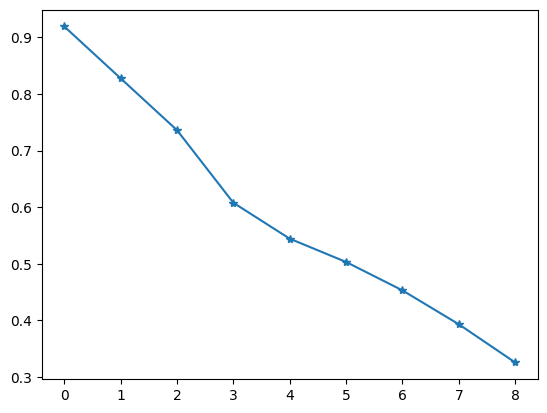

In [21]:
from scipy.sparse.linalg import eigsh
# P = L / L.sum(axis=1)[:, np.newaxis]
diff_eig, diff_ev = eigsh(M,k=10,which='LA')
diff_inv_mes = op_calc.stationary_distribution(M)
diff_eigvecs = diff_ev / np.sqrt((diff_ev**2 * diff_inv_mes[:, None]).sum(axis=0))

sorted_indices = np.argsort(diff_eig.real)[::-1]
diff_eig = diff_eig[sorted_indices].real
diff_eig[diff_eig<1e-12] = 0
diff_dists = diff_eig*(diff_eigvecs[:,sorted_indices].real)

plt.plot(diff_eig[1:],marker='*')
# 
# plt.axhline(ma.mean(max_eigs),c='k')
# cil = np.nanpercentile(max_eigs,2.5)
# ciu = np.nanpercentile(max_eigs,97.5)
# plt.axhspan(cil,ciu,color='k',alpha=.3)

# plt.plot(diff_eig[1:],marker='*')
# plt.axhline(0)

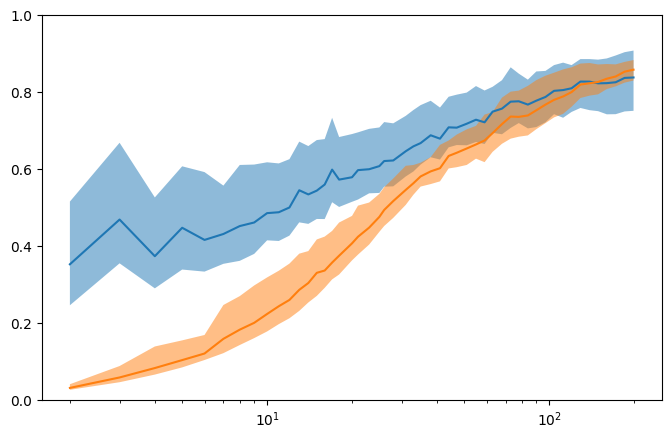

In [22]:
conds_to_comp = [[9],[10]]
cond_recs1 = []
cond_recs2 = []
for c in conds_to_comp[0]:
    cond_recs1.append(np.where(conditions[:,1] == condition_labels[c])[0])
cond_recs1 = np.hstack(cond_recs1)

for c in conds_to_comp[1]:
    cond_recs2.append(np.where(conditions[:,1] == condition_labels[c])[0])
cond_recs2 = np.hstack(cond_recs2)


D_here = Dc_q_data[:,cond_recs1,:][:,:,cond_recs2]
Eps_here = Dc_q_eps[:,cond_recs1,:][:,:,cond_recs2]


plt.figure(figsize=(8,5))
mean = D_here.max(axis=2).mean(axis=1)
# mean= np.median(Dc_q_data.max(axis=2),axis=1)
cil = np.percentile(D_here.max(axis=2),2.5,axis=1)
ciu =  np.percentile(D_here.max(axis=2),97.5,axis=1)
plt.plot(q_range,mean,label='data')
plt.fill_between(q_range,cil,ciu,alpha=.5)

mean = Eps_here.max(axis=2).mean(axis=1)
# mean = np.median(Dc_q_eps.max(axis=2),axis=1)
cil = np.percentile(Eps_here.max(axis=2),2.5,axis=1)
ciu =  np.percentile(Eps_here.max(axis=2),97.5,axis=1)
plt.plot(q_range,mean,label='eps')
plt.fill_between(q_range,cil,ciu,alpha=.5)
# plt.axvline(20,c='k',ls='--')
# plt.axvline(3,c='k',ls='--')
# plt.axvline(12,c='k',ls='--')
# plt.axvline(91,c='k',ls='--')
plt.xscale('log')
# plt.yscale('log')
# plt.xlabel('q')
# plt.ylabel('<D>')
plt.ylim(0,1.0)
# plt.savefig(Fig_path+'/dist_v_eps_light_sensory.pdf')
plt.show()

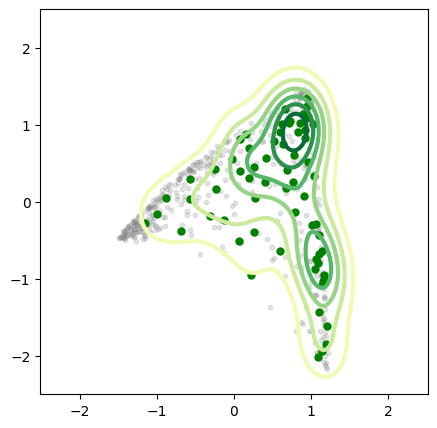

In [77]:
fig, ax = plt.subplots(1,1,figsize=(5,5))
from scipy.stats import gaussian_kde
cmaps = ['YlGn']
colors_ = ['Green']
nonpc_cond_recs = np.arange(0,193)

plt.scatter(diff_dists[:,1],diff_dists[:,2],c='grey',alpha=0.2,s=10)

for i,cond in enumerate([9]):
    idx = np.where(conditions[:,1] == condition_labels[cond])[0]
    plt.scatter(diff_dists[idx,1],diff_dists[idx,2],c=colors_[i],alpha=1,s=25)
    values = diff_dists[idx,1:3].T
    kernel = gaussian_kde(values,bw_method=0.4)
    X,Y = np.meshgrid(np.linspace(-2.5,2.5,200),np.linspace(-2.5,2.5,200))
    positions = np.vstack([X.ravel(), Y.ravel()])
    img = np.reshape(kernel(positions).T, X.shape)
    plt.contour(X,Y, img, cmap=cmaps[int(i)], linewidths=3)

    X = diff_dists[idx,1:3]
    X = X - np.mean(X,axis=0)
    cov = np.cov(X.T)
    e1, ev2 = np.linalg.eig(cov)
    ms = [np.median(diff_dists[idx,1],axis=0),np.median(diff_dists[idx,2],axis=0)]
    
    # plt.colorbar()
plt.axis('equal')
# plt.savefig(Fig_path+'dataset_densities_pcrotrw.pdf')
plt.show()

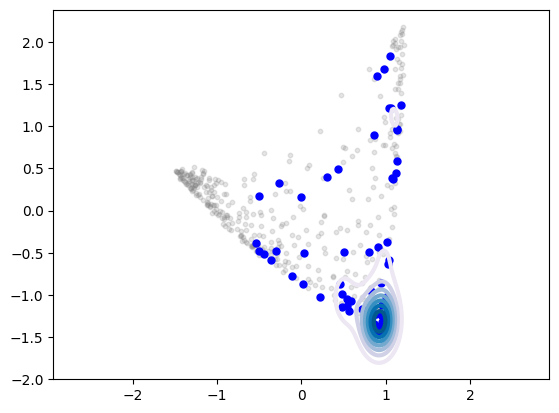

In [23]:
fig, ax = plt.subplots(1,1)
from scipy.stats import gaussian_kde
cmaps = ['PuBu']
colors_ = ['Blue']
nonpc_cond_recs = np.arange(0,193)

plt.scatter(diff_dists[:,1],diff_dists[:,2],c='grey',alpha=0.2,s=10)

for i,cond in enumerate([10]):
    idx = np.where(conditions[:,1] == condition_labels[cond])[0]
    plt.scatter(diff_dists[idx,1],diff_dists[idx,2],c=colors_[i],alpha=1,s=25)
    
    values = diff_dists[idx,1:3].T
    kernel = gaussian_kde(values,bw_method=0.25)
    X,Y = np.meshgrid(np.linspace(-2,2,200),np.linspace(-2,2,200))
    positions = np.vstack([X.ravel(), Y.ravel()])
    img = np.reshape(kernel(positions).T, X.shape)
    plt.contour(X,Y, img, cmap=cmaps[int(i)], linewidths=3)

    X = diff_dists[idx,1:3]
    X = X - np.mean(X,axis=0)
    cov = np.cov(X.T)
    e1, ev2 = np.linalg.eig(cov)
    ms = [np.median(diff_dists[idx,1],axis=0),np.median(diff_dists[idx,2],axis=0)]
    
    # plt.colorbar()
plt.axis('equal')
# plt.savefig(Fig_path+'dataset_densities_pcparamrw.pdf')
plt.show()

In [28]:
path_to_filtered_data = '/flash/StephensU/Gautam/Multiscale_phenotypic_variation/Results/Zebrafish/'
f =  h5py.File(path_to_filtered_data + '/cg_labels_tree_minrho.h5')
labels_tree = np.array(f['labels_tree'],dtype=int)
print(f.keys())
f.close()

<KeysViewHDF5 ['labels_tree']>


In [25]:
## Load symbolic sequences

path_to_filtered_data = '/bucket/StephensU/Gautam/HMD/Results/Zebrafish/'
f = h5py.File(path_to_filtered_data + 'microstate_labels.h5')
lengths_all = np.array(f['MetaData/lengths_data'], dtype=int)
labels_fish_allrec = ma.array(f['labels_fish'],dtype=int)
state_trajs = ma.array(f['state_trajs'])
f.close()

# lengths_all = np.load('/Users/gautam.sridhar/Documents/Repos/ZebraBouts/Datasets/Full_Data/lengths_ex2_recordings.npy')
# lengths_all = lengths

In [26]:
# recs_ = np.asarray(conditions[:,0], dtype=int)

to_mask = 1300

# maxL = np.max(lengths_all[recs_])
maxL = np.max(lengths_all)

labels_fish_allrec[labels_fish_allrec == to_mask] = ma.masked

# labels_fishrec = to_mask * ma.ones((len(recs_), maxL))
# labels_fishrec = labels_fish_allrec[recs_,:maxL+2]
# labels_fishrec = np.delete(labels_fishrec,4,0)

# labels_fishrec[labels_fishrec == to_mask] = ma.masked
labels_fish = labels_fish_allrec

# lengths_rem = np.delete(lengths_all, recs_remove)
lengths_rem = lengths_all

In [29]:
Qlabels = labels_tree[18]
qlabels_fish=ma.zeros(labels_fish.shape,dtype=int)
for kf in range(len(labels_fish)):
    sel = ~labels_fish[kf].mask
    qlabels_fish[kf,sel] = ma.array(Qlabels)[labels_fish[kf][sel]]
    qlabels_fish[kf,~sel] = ma.masked

In [30]:
nstates  = np.unique(Qlabels).shape[0]

In [31]:
f_0,f_f = condition_recs[9]
p_naive=np.zeros((f_f-f_0,nstates))
for kf in range(f_0,f_f):
    l,c = np.unique(qlabels_fish[kf].compressed(),return_counts=True)
    p_naive[kf-f_0,l]=c/c.sum()

f_0,f_f = condition_recs[10]

p_rw=np.zeros((f_f-f_0,nstates))
for kf in range(f_0,f_f):
    l,c = np.unique(qlabels_fish[kf].compressed(),return_counts=True)
    p_rw[kf-f_0,l]=c/c.sum()

ratio_data=np.log2(p_rw.mean(axis=0)/p_naive.mean(axis=0))
diff_data = p_rw.mean(axis=0)-p_naive.mean(axis=0)

In [32]:
p_all = np.vstack([p_naive,p_rw])
nboot=5000
diff_perm = np.zeros((nboot,nstates))
for i in range(nboot):
    perm = np.random.permutation(len(p_all))
    p_naive_perm = p_all[perm[:len(p_naive)]]
    p_rw_perm = p_all[perm[len(p_naive):]]
    diff_perm[i] = p_rw_perm.mean(axis=0)-p_naive_perm.mean(axis=0)

pvals = (np.sum(np.abs(diff_perm) >= np.abs(diff_data), axis=0) + 1) / (nboot + 1)

In [33]:
ratio_boot = np.zeros((nboot,nstates))

for i in range(nboot):
    sel_rw = np.random.randint(0,len(p_rw),len(p_rw))
    sel_naive = np.random.randint(0,len(p_naive),len(p_naive))
    ratio_boot[i] = np.log2(p_rw[sel_rw].mean(axis=0)/p_naive[sel_naive].mean(axis=0))
cil_ratio = np.percentile(ratio_boot,2.5,axis=0)
ciu_ratio = np.percentile(ratio_boot,97.5,axis=0)

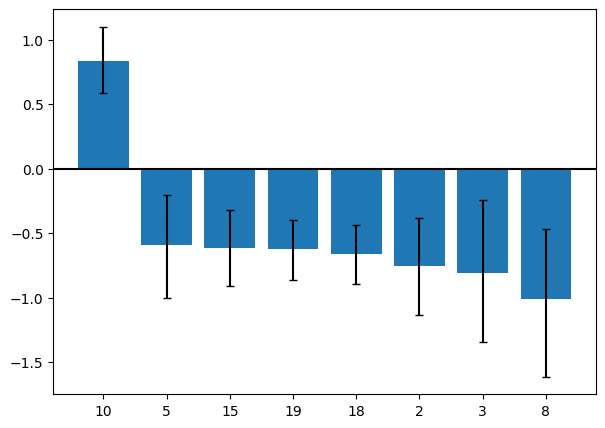

In [34]:
plt.figure(figsize=(7,5))

sel = np.logical_and(pvals<0.01,np.abs(ratio_data)>0.5)
sel_state = np.arange(nstates)[sel][np.argsort(ratio_data[sel])]
sel_state = sel_state[np.argsort(ratio_data[sel_state])[::-1]]

plt.bar(np.arange(len(sel_state)),ratio_data[sel_state],yerr = [ratio_data[sel_state]-cil_ratio[sel_state],
                                                                    ciu_ratio[sel_state]-ratio_data[sel_state]],capsize=3)
plt.axhline(0,c='k')
plt.xticks(np.arange(len(sel_state)),np.arange(20)[sel_state])
# plt.savefig('log_fold_change_paramecia_min_logratio=0.5_minpvalue=0.01.pdf')
plt.show()


In [37]:
bout_type_labels = dict([[1,'Short_CS'],
[2,'Long_CS'],
[3, 'BS'],
[4,'O_bend'],
[5,'J_turn'],
[6,'SLC'],
[7,'Slow1'],
[8,'RT'],
[9,'Slow2'],
[10,'LLC'],
[11,'AS'],
[12,'SAT'],
[13,'HAT']])

In [38]:
print(sel_state)

[10  5 15 19 18  2  3  8]


In [42]:
bout_types[bout_types>13]=ma.masked

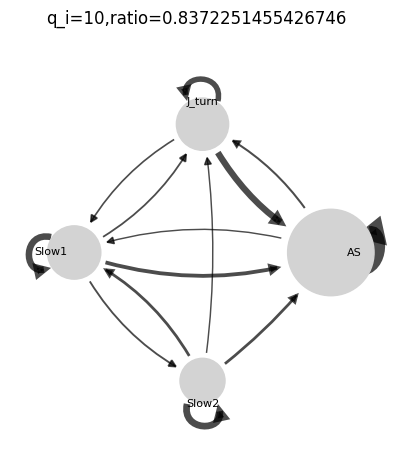

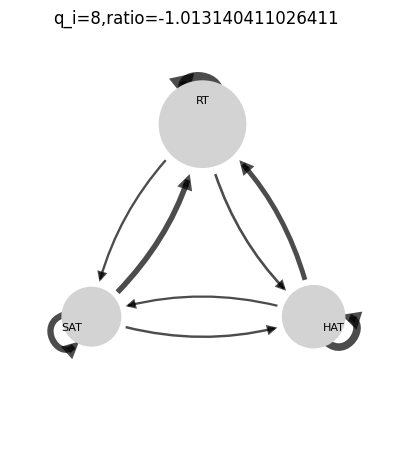

In [57]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from matplotlib.path import Path

def regular_polygon_np(n, radius=1.0, center=(0.0, 0.0), start_angle=np.pi/2):
    theta = start_angle + 2*np.pi*np.arange(n)/n
    return np.column_stack((center[0] + radius*np.cos(theta),
                            center[1] + radius*np.sin(theta)))


p_thresh = 0.1
labels_all = np.array(list(bout_type_labels.values()))

for q_i in [sel_state[0],sel_state[-1]]:
    P_c = op_calc.transition_matrix(
        ma.array([ma.hstack(bout_types)[ma.hstack(qlabels_fish) == q_i]], dtype=int), delay=1)
    pi = op_calc.stationary_distribution(P_c)
    sel = pi > p_thresh
    n = sel.sum()
    
    cs = regular_polygon_np(n)
    P_red = P_c.toarray()[sel, :][:, sel]
    
    labels_sel = np.asarray(labels_all)[sel]
    
    sizes = pi[sel] * 10000
    rad_pt = np.sqrt(sizes / np.pi)
    
    fig, ax = plt.subplots(figsize=(5, 5))
    plt.suptitle('q_i={},ratio={}'.format(q_i,ratio_data[q_i]))
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    
    ax.scatter(
        cs[:, 0], cs[:, 1],
        s=sizes,
        zorder=3,
        c='lightgray'
    )
    
    # labels pushed radially outward
    for i in range(n):
        u = cs[i] / np.linalg.norm(cs[i])
        ax.text(
            *(cs[i] + 0.18 * u),
            labels_sel[i],
            ha='center',
            va='center',
            fontsize=8,
            zorder=4
        )
    
    edge_thresh = p_thresh
    self_thresh = edge_thresh   # or use edge_thresh if you want all self-transitions
    
    mask = ~np.eye(n, dtype=bool)
    pmax = max(P_red[mask].max(), np.diag(P_red).max())
    
    # -------------------------------------------------------------------------
    # self-transition arrows
    # -------------------------------------------------------------------------
    for i in range(n):
        if P_red[i, i] < self_thresh:
            continue
    
        c = cs[i]
    
        # outward radial direction
        u = c / np.linalg.norm(c)
    
        # perpendicular direction
        v = np.array([-u[1], u[0]])
    
        # loop geometry in data coordinates
        loop_offset = 0.18
        loop_width  = 0.12
        loop_height = 0.22
    
        start = c + loop_offset * u - loop_width * v
        end   = c + loop_offset * u + loop_width * v
    
        ctrl1 = c + (loop_offset + loop_height) * u - 1.4 * loop_width * v
        ctrl2 = c + (loop_offset + loop_height) * u + 1.4 * loop_width * v
    
        path = Path(
            [start, ctrl1, ctrl2, end],
            [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4]
        )
    
        arr = FancyArrowPatch(
            path=path,
            arrowstyle='-|>',
            mutation_scale=12,
            # linewidth=0.5 + 4 * P_red[i, i] / pmax,
            linewidth = 20*P_red[i,i],
            color='k',
            alpha=0.7,
            zorder=2,
            joinstyle='miter',
            capstyle='butt'
        )
    
        arr.set_gid(f'self_edge_{i}')
        ax.add_patch(arr)
    
    
    # -------------------------------------------------------------------------
    # normal non-self transition arrows
    # -------------------------------------------------------------------------
    for i in range(n):
        for j in range(n):
    
            if i == j:
                continue
    
            if P_red[i, j] < edge_thresh:
                continue
    
            if P_red[j, i] >= edge_thresh:
                curve = 0.18
            else:
                curve = 0.08
    
            arr = FancyArrowPatch(
                posA=cs[i],
                posB=cs[j],
                connectionstyle=f"arc3,rad={curve}",
                arrowstyle='-|>',
                mutation_scale=12,
                shrinkA=rad_pt[i] + 2,
                shrinkB=rad_pt[j] + 2,
                # linewidth=0.5 + 4 * P_red[i, j] / pmax,
                linewidth = 10*P_red[i,j],
                color='k',
                alpha=0.7,
                zorder=2,
                joinstyle='miter',
                capstyle='butt'
            )
    
            arr.set_gid(f'edge_{i}_{j}')
            ax.add_patch(arr)
    
    # fig.savefig(f'trans_matrix_q_i_{q_i}.svg', bbox_inches='tight')
    # fig.savefig(f'trans_matrix_q_i_{q_i}.pdf', bbox_inches='tight')
    plt.show()

### Time spent in q_i=10

In [46]:
def get_errorbar_dist(lifetimes_w,t0,tf):
    all_lt = np.hstack(lifetimes_w)
    x,y = stats.complementary_cumulative_dist(all_lt,(t0,tf))
    y_all = np.array([np.mean(y[x==x_unique]) for x_unique in np.unique(x)])
    x_all = np.sort(np.unique(x))
    
    dict_y = {}
    for x_ in x_all:
        dict_y[x_] = []

    for k in range(1000):
        sel_indices = np.random.randint(0,len(lifetimes_w),len(lifetimes_w))
        x,y = stats.cumulative_dist(np.hstack([lifetimes_w[k] for k in sel_indices]),(t0,tf))
        y = 1-np.array([np.mean(y[x==x_unique]) for x_unique in np.unique(x)])
        x = np.sort(np.unique(x))
        for kx in range(len(y)):
            dict_y[x[kx]].append(y[kx])
            
    y_errorbars = np.zeros((len(dict_y.keys()),3))
    for kx,x_ in enumerate(x_all):
        values = np.array(dict_y[x_])
        values = values[values>0]
        cil = np.percentile(values,2.5)
        ciu = np.percentile(values,97.5)
        y_errorbars[kx] = [y_all[kx],cil,ciu]
    return x_all[:-1],y_errorbars[:-1]

In [47]:
idx=9
print(condition_labels[idx])
f_0,f_f = condition_recs[idx]

dts_naive = []

for kf in range(f_0,f_f):
    mask = qlabels_fish[kf]==10
    segments = np.where(np.abs(np.diff(np.concatenate([[False], mask, [False]]))))[0].reshape(-1, 2)
    dts_naive.append(np.hstack(np.diff(segments,axis=1)))


idx=10
print(condition_labels[idx])
f_0,f_f = condition_recs[idx]

dts_rw = []

for kf in range(f_0,f_f):
    mask = qlabels_fish[kf]==10
    segments = np.where(np.abs(np.diff(np.concatenate([[False], mask, [False]]))))[0].reshape(-1, 2)
    dts_rw.append(np.hstack(np.diff(segments,axis=1)))

logmean_dts_naive = [np.mean(np.log10(dts_naive[kf])) for kf in range(len(dts_naive))]
logmean_dts_rw = [np.mean(np.log10(dts_rw[kf])) for kf in range(len(dts_rw))]
diff_data = np.mean(logmean_dts_rw)-np.mean(logmean_dts_naive)
print(diff_data)
dts_all = np.hstack([logmean_dts_naive,logmean_dts_rw])
n_naive = len(logmean_dts_naive)
nboot=100000
diff_perm = np.zeros((nboot))
for i in range(nboot):
    perm = np.random.permutation(len(dts_all))
    dts_naive_perm = dts_all[perm[:n_naive]]
    dts_rw_perm = dts_all[perm[n_naive:]]
    diff_perm[i] = dts_rw_perm.mean(axis=0)-dts_naive_perm.mean(axis=0)

pval = (np.sum(np.abs(diff_perm) >= np.abs(diff_data), axis=0) + 1) / (nboot + 1)
print(pval)



Prey Capture Param. (2.5x2.5cm)
Prey Capture Param. RW. (2.5x2.5cm)
0.03789766772494185
0.00034999650003499967


1.4984304088975564 1.4530307701203329 1.5459311519993855


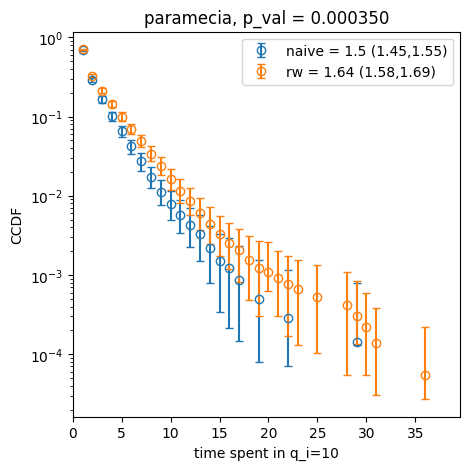

In [48]:
plt.figure(figsize=(5,5))
plt.title('paramecia, p_val = {:.6f}'.format(pval))
x,y = get_errorbar_dist(dts_naive,0,60)
# sel=x<15]
# x = x[x<15]
# y = y[y[:,0]<15,:]
mean,cil,ciu = stats.bootstrap([np.mean(np.log10(dts_naive[kf])) for kf in range(len(dts_naive))],n_times=10000)
print(10**mean,10**cil[0],10**ciu[0])

plt.errorbar(x,y[:,0],yerr = [y[:,0]-y[:,1],y[:,2]-y[:,0]],label='naive = {:.3} ({:.3},{:.3})'.format(10**mean,10**cil[0],10**ciu[0]),capsize=3,fmt='o',mfc='none')
x,y = get_errorbar_dist(dts_rw,0,60)
mean,cil,ciu = stats.bootstrap([np.mean(np.log10(dts_rw[kf])) for kf in range(len(dts_rw))],n_times=10000)
plt.errorbar(x,y[:,0],yerr = [y[:,0]-y[:,1],y[:,2]-y[:,0]],label='rw = {:.3} ({:.3},{:.3})'.format(10**mean,10**cil[0],10**ciu[0]),capsize=3,fmt='o',mfc='none')
plt.yscale('log')
plt.legend()
plt.xlabel('time spent in q_i=10')
plt.ylabel('CCDF')
plt.xlim(0*x.min(),x.max()*1.1)
# plt.savefig('time_in_q_i_10_paramecia.pdf')
# plt.xscale('log')
plt.show()

### Entropy calculation

In [7]:
from scipy.spatial.distance import cdist

In [8]:
import numpy as np

def gaussian_kde_2d(X, bandwidth, xmin, xmax, ymin, ymax,
                         nx=100, ny=100, return_centers=True):

    x_edges = np.linspace(xmin, xmax, nx + 1)
    y_edges = np.linspace(ymin, ymax, ny + 1)

    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
    y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])

    xx, yy = np.meshgrid(x_centers, y_centers, indexing="xy")
    Q = np.column_stack([xx.ravel(), yy.ravel()])

    h2 = bandwidth ** 2
    diff = Q[:, None, :] - X[None, :, :]
    sqdist = np.sum(diff ** 2, axis=2)

    density_flat = (
        np.exp(-0.5 * sqdist / h2).sum(axis=1)
        / (len(X) * 2 * np.pi * h2)
    )

    density = density_flat.reshape(ny, nx)

    if return_centers:
        return density, x_centers, y_centers

    return density

In [9]:
def get_continuous_entropy(Xp, ngrid=50,xmin=-2, xmax=2.5,ymin=-2, ymax=2.5, bw=0.1):

    D, _, _ = gaussian_kde_2d(Xp, bw, xmin, xmax, ymin, ymax,nx=ngrid, ny=ngrid,return_centers=True)

    dx = (xmax - xmin) / ngrid
    dy = (ymax - ymin) / ngrid
    cell_area = dx * dy

    # Normalize KDE conditional on being inside the domain.
    p_density = D / (D.sum() * cell_area)

    p_density = p_density[p_density>0]

    return -np.sum(p_density * np.log2(p_density)) * cell_area

In [10]:
def compute_entropy_ratio(X_naive,X_rw,ngrid,xmin,xmax,ymin,ymax,bw,nboot):
    n_naive = X_naive.shape[0]
    n_rw = X_rw.shape[0]    
    npoints = int(min(n_naive,n_rw))    
    ratios = np.zeros(nboot)
    for i in range(nboot):
        sel_naive = np.random.choice(np.arange(0,len(X_naive)),npoints,replace=True)
        h_naive = get_continuous_entropy(X_naive[sel_naive],ngrid,xmin,xmax,ymin,ymax,bw)
        sel_rw = np.random.choice(np.arange(0,len(X_rw)),npoints,replace=True)
        h_rw = get_continuous_entropy(X_rw[sel_rw],ngrid,xmin,xmax,ymin,ymax,bw)
        ratios[i] = h_rw-h_naive
    return ratios

def bootstrap_equal_n_entropy_difference(X_naive, X_rw,ngrid, xmin, xmax, ymin, ymax, bw,nboot):
    n_equal = min(len(X_naive), len(X_rw))
    delta_boot = np.empty(nboot)

    for b in range(nboot):
        idx_naive = np.random.choice(
            len(X_naive), size=n_equal, replace=True
        )
        idx_rw = np.random.choice(
            len(X_rw), size=n_equal, replace=True
        )

        h_naive = get_continuous_entropy(
            X_naive[idx_naive],
            ngrid, xmin, xmax, ymin, ymax, bw
        )

        h_rw = get_continuous_entropy(
            X_rw[idx_rw],
            ngrid, xmin, xmax, ymin, ymax, bw
        )

        delta_boot[b] = h_rw - h_naive

    return delta_boot


def permutation_test_equal_n_entropy(X_naive, X_rw,ngrid, xmin, xmax, ymin, ymax, bw,nperm,n_inner=10):
    n_naive = len(X_naive)
    n_rw = len(X_rw)
    n_equal = min(n_naive, n_rw)

    def equal_n_delta(Xa, Xb):
        """
        Returns mean H_b - H_a over random equal-size subsets.
        Xa is naive; Xb is RW.
        """
        deltas = np.empty(n_inner)

        for j in range(n_inner):
            ia = np.random.choice(len(Xa), n_equal, replace=False)
            ib = np.random.choice(len(Xb), n_equal, replace=False)

            h_a = get_continuous_entropy(
                Xa[ia], ngrid, xmin, xmax, ymin, ymax, bw
            )
            h_b = get_continuous_entropy(
                Xb[ib], ngrid, xmin, xmax, ymin, ymax, bw
            )

            deltas[j] = h_b - h_a

        return deltas.mean()

    # Observed equal-n statistic.
    delta_obs = equal_n_delta(X_naive, X_rw)

    X_pooled = np.vstack([X_naive, X_rw])
    delta_perm = np.empty(nperm)

    for b in range(nperm):
        idx = np.random.permutation(len(X_pooled))

        X_naive_perm = X_pooled[idx[:n_naive]]
        X_rw_perm = X_pooled[idx[n_naive:n_naive + n_rw]]

        delta_perm[b] = equal_n_delta(X_naive_perm, X_rw_perm)

    # Directional hypothesis: RW has lower entropy.
    p_rw_lower_entropy = (
        1 + np.sum(delta_perm <= delta_obs)
    ) / (nperm + 1)

    p_two_sided = (
        1 + np.sum(np.abs(delta_perm) >= np.abs(delta_obs))
    ) / (nperm + 1)

    return  p_rw_lower_entropy, p_two_sided

In [14]:
kc = 9
k0,kf = condition_recs[kc]
X_naive = diff_dists[k0:kf,1:3]
kc = 10
k0,kf = condition_recs[kc]
X_rw = diff_dists[k0:kf,1:3]
X_all = np.vstack([X_naive,X_rw])

np.median(np.sort(cdist(X_all,X_all),axis=1)[:,1]) # median nearest neighbor distance

np.float64(0.06621598637029485)

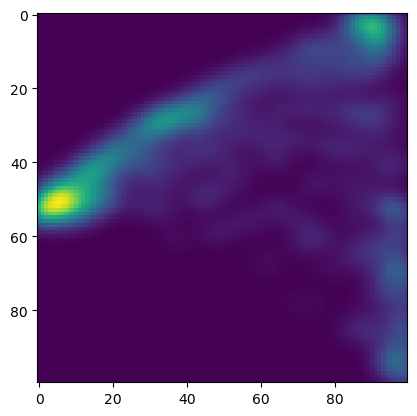

0.1 -1.002314317500901 [-1.5279219 -0.5473974] 0.3670290359725201 [0.21698612 0.57845333] 0.0001999600079984003
0.1 0.05761726065433391 [-0.49850674  0.62436256] 1.0593094800903318 [0.60743705 1.86705544] 0.09638072385522896


In [15]:
ngrid=100
xmin=diff_dists[:,1].min()
xmax=diff_dists[:,1].max()
ymin=diff_dists[:,2].min()
ymax=diff_dists[:,2].max()
nboot=5000
nperm=5000

bw=0.1

kc = 9
k0,kf = condition_recs[kc]
X_naive = diff_dists[k0:kf,1:3]
kc = 10
k0,kf = condition_recs[kc]
X_rw = diff_dists[k0:kf,1:3]
X_all = np.vstack([X_naive,X_rw])


D, _, _ = gaussian_kde_2d(diff_dists[:,1:3], bw, xmin, xmax, ymin, ymax,nx=ngrid, ny=ngrid,return_centers=True)
plt.imshow(D)
plt.show()

delta_subsample_param = compute_entropy_ratio(X_naive, X_rw,ngrid, xmin, xmax, ymin, ymax, bw,nboot)

median_delta_param = np.median(delta_subsample_param)

median_ratio_param = np.median(np.exp(delta_subsample_param))

delta_boot_param = bootstrap_equal_n_entropy_difference(X_naive, X_rw,ngrid, xmin, xmax, ymin, ymax, bw,nboot)

ci_delta_param = np.quantile(delta_boot_param, [0.025, 0.975])
ci_ratio_param = np.exp(ci_delta_param)    

p_rw_lower_entropy_param,_ = permutation_test_equal_n_entropy(X_naive, X_rw,ngrid,xmin, xmax,ymin, ymax,bw,nperm,n_inner=10)

print(bw, median_delta_param,ci_delta_param, median_ratio_param,ci_ratio_param,p_rw_lower_entropy_param)


kc = 11
k0,kf = condition_recs[kc]
X_naive = diff_dists[k0:kf,1:3]
kc = 12
k0,kf = condition_recs[kc]
X_rw = diff_dists[k0:kf,1:3]
X_all = np.vstack([X_naive,X_rw])

delta_subsample_rot = compute_entropy_ratio(X_naive, X_rw,ngrid, xmin, xmax, ymin, ymax, bw,nboot)

median_delta_rot = np.median(delta_subsample_rot)

median_ratio_rot = np.median(np.exp(delta_subsample_rot))

delta_boot_rot = bootstrap_equal_n_entropy_difference(X_naive, X_rw,ngrid, xmin, xmax, ymin, ymax, bw,nboot)

ci_delta_rot = np.quantile(delta_boot_rot, [0.025, 0.975])
ci_ratio_rot = np.exp(ci_delta_rot)    

p_rw_lower_entropy_rot,_ = permutation_test_equal_n_entropy(X_naive, X_rw,ngrid,xmin, xmax,ymin, ymax,bw,nperm,n_inner=10)

print(bw, median_delta_rot,ci_delta_rot, median_ratio_rot,ci_ratio_rot,p_rw_lower_entropy_rot)

# Check dependency on bandwidth

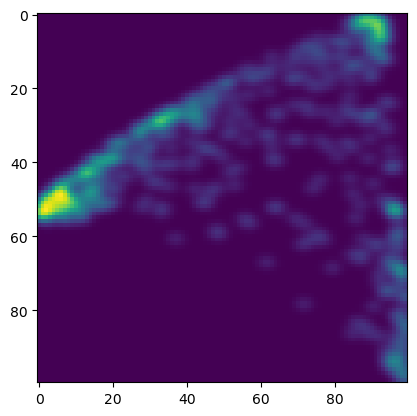

0.05 -0.8455124538787072 [-1.30931343 -0.40761413] 0.4293372867885862 [0.27000537 0.66523552] 0.0001999600079984003
0.05 0.2682864069581911 [-0.29251106  0.84401419] 1.3077216311489592 [0.74638699 2.32568401] 0.0625874825034993


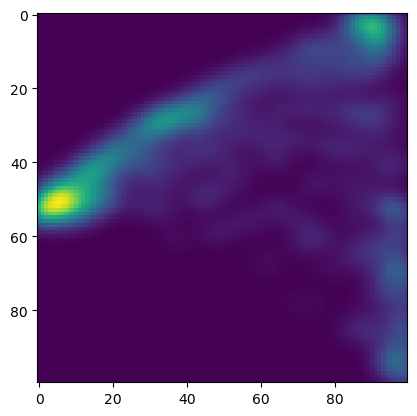

0.1 -1.0065469338333712 [-1.51835488 -0.54540668] 0.3654788258294041 [0.21907199 0.57960602] 0.0001999600079984003
0.1 0.055388019954275516 [-0.50376951  0.60673189] 1.0569506606101386 [0.60424864 1.83442648] 0.026194761047790442


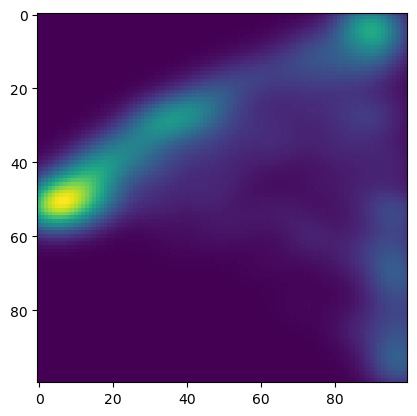

0.15 -0.9198611094778151 [-1.42760938 -0.47497454] 0.398574396347954 [0.2398817  0.62190089] 0.0001999600079984003
0.15 -0.022269831000115925 [-0.61192866  0.5383878 ] 0.9779763115091676 [0.54230394 1.71324255] 0.014397120575884824


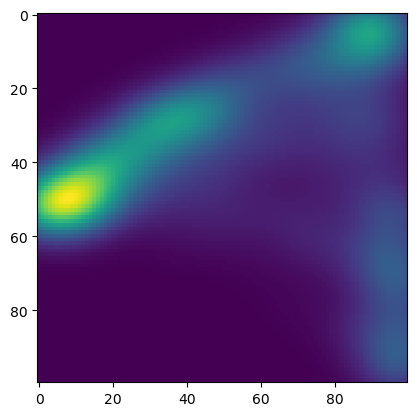

0.2 -0.8066412188805805 [-1.28811117 -0.37044106] 0.4463547592224155 [0.27579121 0.69042975] 0.0003999200159968006
0.2 -0.031445157868048024 [-0.56888315  0.52741875] 0.9690441112706697 [0.5661574 1.6945526] 0.15076984603079385


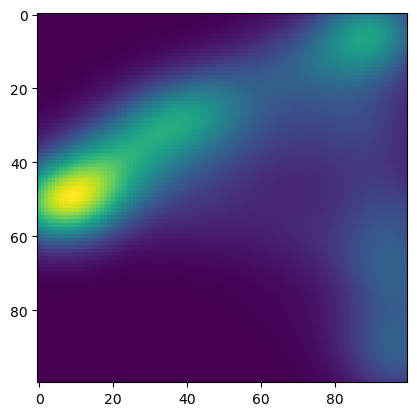

0.25 -0.7060636279281177 [-1.15778255 -0.31155196] 0.4935833367995656 [0.31418209 0.73230956] 0.0003999200159968006
0.25 -0.0183768075542603 [-0.52853008  0.50919154] 0.9817910166725803 [0.58947081 1.66394542] 0.2907418516296741


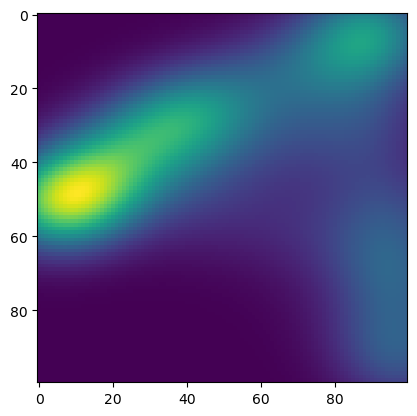

0.3 -0.6189383943349369 [-1.06532303 -0.24303994] 0.538515825733132 [0.34461651 0.78424019] 0.0005998800239952009
0.3 -0.0006232722206462871 [-0.46467563  0.51686872] 0.999376929004842 [0.62833889 1.67676899] 0.23695260947810437


In [16]:
ngrid=100
xmin=diff_dists[:,1].min()
xmax=diff_dists[:,1].max()
ymin=diff_dists[:,2].min()
ymax=diff_dists[:,2].max()

for bw in [0.05,0.1,0.15,0.2,0.25,0.3]:
    
    kc = 9
    k0,kf = condition_recs[kc]
    X_naive = diff_dists[k0:kf,1:3]
    kc = 10
    k0,kf = condition_recs[kc]
    X_rw = diff_dists[k0:kf,1:3]
    X_all = np.vstack([X_naive,X_rw])


    D, _, _ = gaussian_kde_2d(
        diff_dists[:,1:3], bw, xmin, xmax, ymin, ymax,
        nx=ngrid, ny=ngrid,
        return_centers=True
    )
    plt.imshow(D)
    plt.show()
    
    delta_subsample_param = compute_entropy_ratio(X_naive, X_rw,ngrid, xmin, xmax, ymin, ymax, bw,nboot)
    
    median_delta_param = np.median(delta_subsample_param)
    
    median_ratio_param = np.median(np.exp(delta_subsample_param))
    
    delta_boot_param = bootstrap_equal_n_entropy_difference(X_naive, X_rw,ngrid, xmin, xmax, ymin, ymax, bw,nboot)
    
    ci_delta_param = np.quantile(delta_boot_param, [0.025, 0.975])
    ci_ratio_param = np.exp(ci_delta_param)    
    
    p_rw_lower_entropy_param,_ = permutation_test_equal_n_entropy(X_naive, X_rw,ngrid,xmin, xmax,ymin, ymax,bw,nperm,n_inner=10)
    
    print(bw, median_delta_param,ci_delta_param, median_ratio_param,ci_ratio_param,p_rw_lower_entropy_param)


    kc = 11
    k0,kf = condition_recs[kc]
    X_naive = diff_dists[k0:kf,1:3]
    kc = 12
    k0,kf = condition_recs[kc]
    X_rw = diff_dists[k0:kf,1:3]
    X_all = np.vstack([X_naive,X_rw])
    
    delta_subsample_rot = compute_entropy_ratio(X_naive, X_rw,ngrid, xmin, xmax, ymin, ymax, bw,nboot)
    
    median_delta_rot = np.median(delta_subsample_rot)
    
    median_ratio_rot = np.median(np.exp(delta_subsample_rot))
    
    delta_boot_rot = bootstrap_equal_n_entropy_difference(X_naive, X_rw,ngrid, xmin, xmax, ymin, ymax, bw,nboot)
    
    ci_delta_rot = np.quantile(delta_boot_rot, [0.025, 0.975])
    ci_ratio_rot = np.exp(ci_delta_rot)    
    
    p_rw_lower_entropy_rot,_ = permutation_test_equal_n_entropy(X_naive, X_rw,ngrid,xmin, xmax,ymin, ymax,bw,nperm,n_inner=10)
    
    print(bw, median_delta_rot,ci_delta_rot, median_ratio_rot,ci_ratio_rot,p_rw_lower_entropy_rot)